In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/online_shoppers_intention.csv')

# 기본 정보 확인
print(df.shape)
print(df.info())
print(df.describe())
print(df['Revenue'].value_counts())

(12330, 18)
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType          

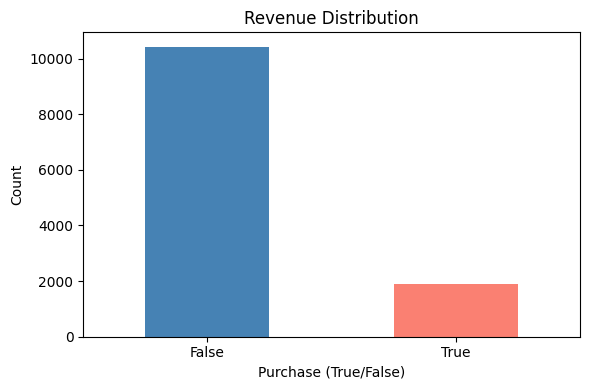

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Revenue 비율 시각화
plt.figure(figsize=(6, 4))
df['Revenue'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Revenue Distribution')
plt.xlabel('Purchase (True/False)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/revenue_distribution.png')
plt.show()

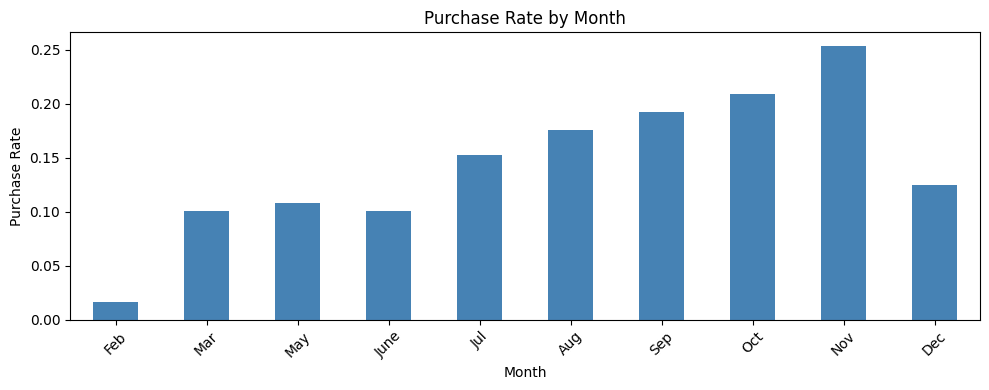

                    sum  count      mean
VisitorType                             
New_Visitor         422   1694  0.249115
Other                16     85  0.188235
Returning_Visitor  1470  10551  0.139323


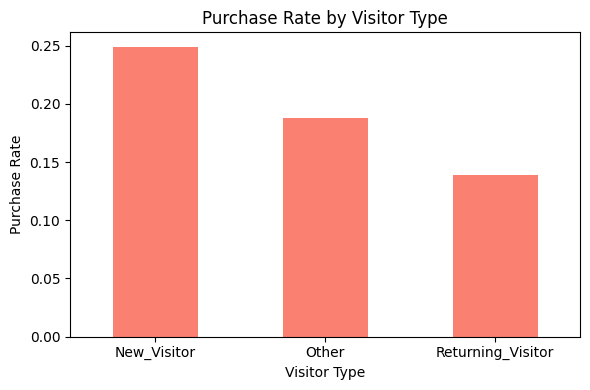

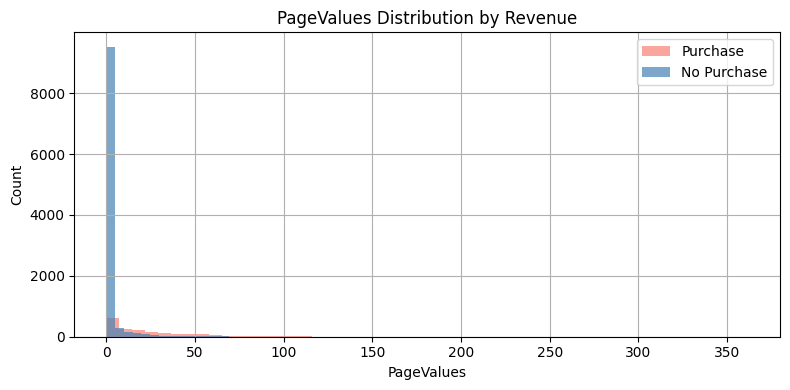

In [ ]:
# 1. 월별 구매 비율
plt.figure(figsize=(10, 4))
month_order = ['Jan','Feb','Mar','Apr','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
month_revenue = df.groupby('Month')['Revenue'].mean().reindex(month_order).dropna()
month_revenue.plot(kind='bar', color='steelblue')
plt.title('Purchase Rate by Month')
plt.xlabel('Month')
plt.ylabel('Purchase Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/purchase_rate_by_month.png')
plt.show()

# 2. 방문자 유형별 구매 비율
print(df.groupby('VisitorType')['Revenue'].agg(['sum', 'count', 'mean']))
plt.figure(figsize=(6, 4))
visitor_revenue = df.groupby('VisitorType')['Revenue'].mean()
visitor_revenue.plot(kind='bar', color='salmon')
plt.title('Purchase Rate by Visitor Type')
plt.xlabel('Visitor Type')
plt.ylabel('Purchase Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/purchase_rate_by_visitor.png')
plt.show()

# 3. PageValues 분포 (구매 여부에 따라)
plt.figure(figsize=(8, 4))
df[df['Revenue']==True]['PageValues'].hist(bins=50, alpha=0.7, color='salmon', label='Purchase')
df[df['Revenue']==False]['PageValues'].hist(bins=50, alpha=0.7, color='steelblue', label='No Purchase')
plt.title('PageValues Distribution by Revenue')
plt.xlabel('PageValues')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/pagevalues_distribution.png')
plt.show()

Graph 1 - Purchase Rate by Month 
11월의 구매율이 압도적으로 높음 = 블랙프라이데이, 사이버먼데이가 11월에 있기 때문
=> 11월에 광고 예산 집중 투자 시, ROI(투자수익률) 높음

Graph 2 - Purchase Rate by Visitor Type
신규 방문자 구매율이 가장 높고, 재방문자 구매율이 낮음 (실제 구매수는 재방문자가 더 많음)
=> 신규 유입 퀄리티가 좋지만, 재방문자 전환율 개선 필요

Graph 3 - PageValues Distribution by Revenue
대부분 0, 구매한 사람만 PageValue가 높음
=> PageValue가 높을수록 구매 가능성 높음